<a href="https://colab.research.google.com/github/beatag-1/Project_cb2330/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import math
import numpy as np
import random
import pandas as pd

####The paper:
Whitman WB, Coleman DC, Wiebe WJ. Prokaryotes: The unseen majority. Proceedings of the National Academy of Sciences [Internet]. 1998 June 9 [cited 2026 Oct 2];95(12):6578–83. Available from: https://www.researchgate.net/publication/13666900_Prokaryotes_The_unseen_majority

####The data object:
The cell density measurements at various depths reported in table 3 in the paper.

####The random variable chosen:
X = Cell density at a certain depth.

####What the paper does:
Calculates the total number of prokaryotes in various environments and estimates the amount of carbon they contain.

####The generative model proposed:
X ~ *N*(c*$e^{-k*d}$, $σ^{2}$)

####Parameters:

c [cells/$cm^{3}$ x $10^{6}$]: cell density at depth = 0, the starting cell density

k [cells/$cm^{3}$ x $10^{6}$ /m]: decay of cell density parameter

An increase in k means that the cell density decreases faster with depth.

sigma [cells/$cm^{3}$ x $10^{6}$]: standard deviation of cell density at various depths

A bigger sigma means that the data is more spread out from the mean.

####Assumptions:
- The cell density decreases exponentially with depth
- The cell density has a Gaussian distribution with the mean value modeled as c*$e^{-k*d}$ and variance $σ^{2}$

####The forward simulation:

Simulating new data points from the estimated parameters. The noise is randomly generated by picking values from a normal distribution with a mean of 0 and standard deviation sigma.

####The parametrization:

The negative-log likelihood is used to score different parameter candidates through a grid search to find the values that minimize the function.

####Does the model add anything to the paper?

Our model investigates if the data can be described by a simple exponential decay model and to what extent the model can reproduce the observed data.


####Model limitations:

Only 10 data points are used and only one measurement per depth. Therefore, the model proposed has very little statistical support. The model cannot properly distinguish noise from true trends of the data.

The constant decay rate is too simple to explain the variations in decay at different depths. It doesn't take biological factors into account that could alter the rate of decay at different depths. At the 300 m depth, the cell density increases. This cannot be explained by an exponential model.

Normal noise might not be the best distribution to describe the variations in the data as it allows negative cell densities.

Using bootstrap with only 10 observations could be uncertain because smaller sample sizes will be more effected by data points being left out compared to larger datasets. For example, the c parameter will be affected a lot if the first data point is left out as it deviates from the rest.

####AI usage:

AI was used discuss project ideas and debugging code.

## The data

Cell_density is the density of prokaryotes measured in cells/cm^3, x 10^6.

This density is measured at various depth intervals in the ocean, measured in meters.
E.g. 0.1 m represents 0.1-10 m.  

In [ ]:
!git clone https://github.com/beatag-1/Project_cb2330.git

Cloning into 'Project_cb2330'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 31 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 244.98 KiB | 8.45 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
%cd Project_cb2330

/content/Project_cb2330


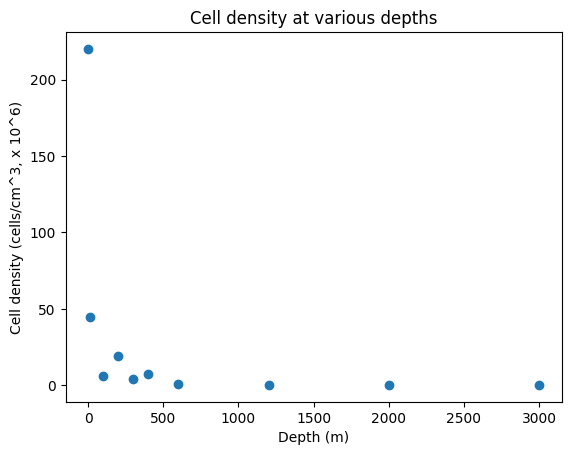

In [ ]:
data = pd.read_csv("data/data.csv")
depth = data["depth"].values
cell_density = data["cell_density"].values

plt.scatter(depth, cell_density)
plt.title('Cell density at various depths')
plt.xlabel('Depth (m)')
plt.ylabel('Cell density (cells/cm^3, x 10^6)')
plt.show()

The random variable chosen is cell density. We assume that the measurement error is normally distributed, and that the mean cell density decays exponentially with increasing depth.

Here the parameters of the probabilistic model are found by minimizing the negative log-likelihood function.

In [ ]:
def function(d, c, k):
  """ Exponential decay function that calculates the cell density at a depth d using parameters c and k """
  return c*math.exp(-k*d)


def normal(x, mu, sigma):
  """ Density function of the normal distribution """
  return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-((x - mu)**2) / (2 * sigma**2))

def nll_normal(depth, cell_density, c, k, sigma):
  """ The negative log-likelihood function for normal distribution, that calculates the negative log-likelihood score with parameters c, k and sigma """
  total = 0.0
  for d, x in zip(depth, cell_density):
    mu = function (d,c,k)
    val = normal(x, mu, sigma)
    total = total-math.log(max(val, 1e-15))
  return total

def scoring(depth, cell_density):
  """ Scores different combinations of c, k and sigma using grid search, and gives the values of the parameters that minimizes the NLL function """
  c_hat = 0.0
  k_hat = 0.0
  sigma_hat = 0.0

  best = float("inf")


  for i in range(200):
    c = 50 + 1 * i
    for j in range(100):
      sigma = 0.2 + 0.5 * j
      for l in range(100):
        k = 0.001 + 0.005 * l
        score = nll_normal(depth, cell_density, c, k, sigma)

        if score < best:
          best = score
          c_hat = c
          k_hat = k
          sigma_hat = sigma
  return c_hat, k_hat, sigma_hat, best


In [ ]:
c_hat, k_hat, sigma_hat, best= scoring(depth, cell_density)
print(f"Estimated c: {c_hat}, estimated k: {k_hat}, estimated sigma: {sigma_hat}")

Estimated c: 224, estimated k: 0.161, estimated sigma: 6.7


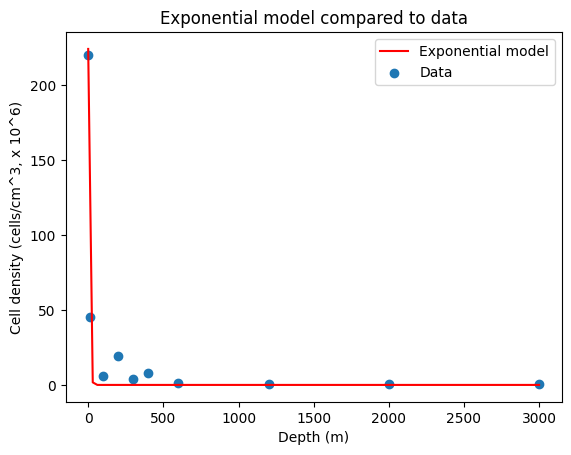

In [ ]:
depth_values = np.linspace(0, 3000, 100)
plt.plot(depth_values, [function(d, c_hat, k_hat) for d in depth_values], color = "red", label = "Exponential model")
plt.scatter(depth, cell_density, label = "Data")
plt.title ('Exponential model compared to data')
plt.xlabel('Depth (m)')
plt.ylabel('Cell density (cells/cm^3, x 10^6)')
plt.legend()
plt.show()

In [ ]:
def forward_model(depth, c, k, sigma, n_simulations):
  """ Simulates cell densities at different depths with Gaussian noise, using the estimated parameters c, k, and sigma """

  mean = [function(d, c, k) for d in depth]

  simulations = np.zeros((n_simulations, len(depth)))

  for i in range(n_simulations):
    noise = np.random.normal(loc=0, scale= sigma, size=len(depth))
    simulations[i, :] = mean + noise


  return simulations


In [ ]:
np.random.seed(5)

simulation1000 = forward_model(depth, c_hat, k_hat, sigma_hat, 1000)

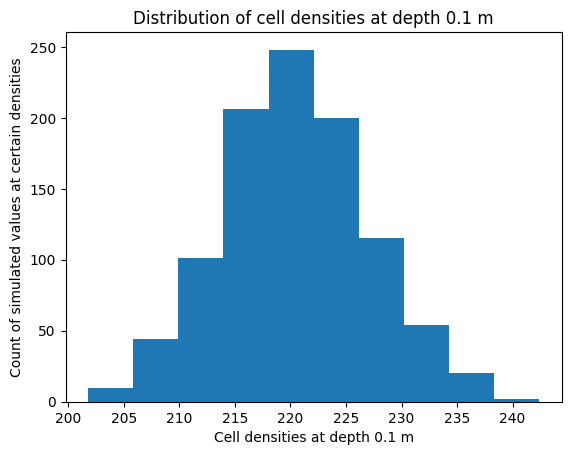

In [ ]:
plt.hist(simulation1000[:,0])
plt.title("Distribution of cell densities at depth 0.1 m")
plt.xlabel("Cell densities at depth 0.1 m")
plt.ylabel("Count of simulated values at certain densities")
plt.show()



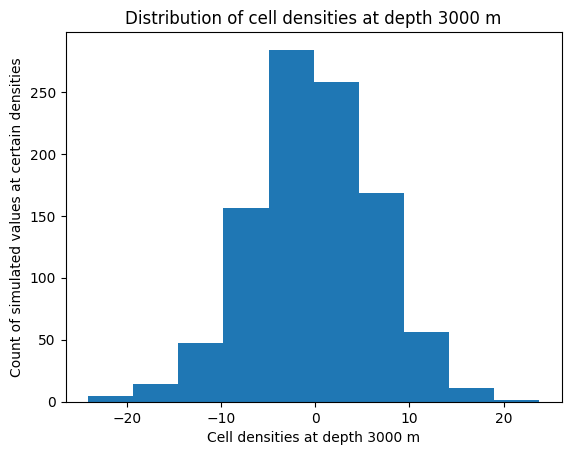

In [ ]:
plt.hist(simulation1000[:, -1])
plt.title("Distribution of cell densities at depth 3000 m")
plt.xlabel("Cell densities at depth 3000 m")
plt.ylabel("Count of simulated values at certain densities")
plt.show()

In [ ]:
simulation10 = forward_model(depth, c_hat, k_hat, sigma_hat, 10)
simulated_values = [simulation10[:, 0], simulation10[:, 1], simulation10[:, 2], simulation10[:, 3], simulation10[:, 4] , simulation10[:, 5], simulation10[:, 6], simulation10[:, 7], simulation10[:, 8], simulation10[:, 9]]
depth_values = [[0.1]*10, [10]*10, [100]*10, [200]*10, [300]*10, [400]*10, [600]*10, [1200]*10, [2000]*10, [3000]*10]



A plot that shows the simulated cell densities at the 10 depths. This shows the limitation of the Gaussian noise distribution, because cell densities become negative at the lower depths.  

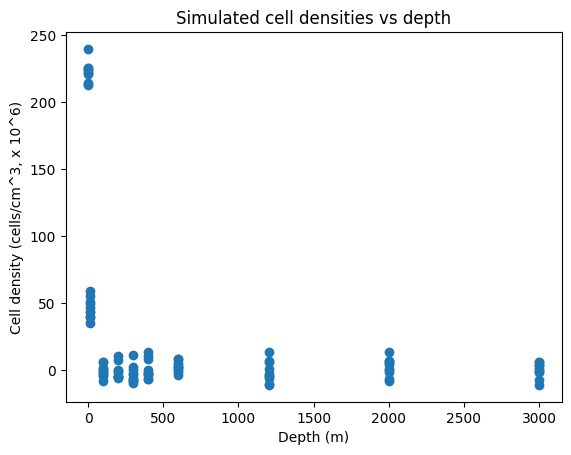

In [ ]:
plt.scatter(depth_values, simulated_values)
plt.title("Simulated cell densities vs depth")
plt.xlabel('Depth (m)')
plt.ylabel('Cell density (cells/cm^3, x 10^6)')
plt.show()

Because grid search would be too exhaustive for many bootstrap resamples, we decided to use random search when scoring the parameter candidates.

In [ ]:
def fast_scoring(depth, cell_density):
  """ Scores different combinations of c, k and sigma using random search, and gives the values of the parameters that minimizes the NLL function """
  c_hat = 0.0
  k_hat = 0.0
  sigma_hat = 0.0

  best = float("inf")


  for i in range(10000):
    c = random.uniform(1, 500)
    k = random.uniform(0.00001, 1)
    sigma = random.uniform(0.1, 100)

    score = nll_normal(depth, cell_density, c, k, sigma)

    if score < best:
      best = score
      c_hat = c
      k_hat = k
      sigma_hat = sigma
  return c_hat, k_hat, sigma_hat, best

An uncertainty analysis is done using bootstrap, where the datapoints are resampled with replacement and the parameters are estimated again with the new resampled dataset.

In [ ]:
np.random.seed(5)

bootstrap_c = []
bootstrap_k = []
bootstrap_sigma = []

depth_array = np.array(depth)
cell_density_array = np.array(cell_density)

for i in range(100):
  picked_indices = np.random.choice(len(depth), size = len(depth), replace = True)

  boot_depth = depth_array[picked_indices]
  boot_cell_density = cell_density_array[picked_indices]
  c, k, sigma, best = fast_scoring(boot_depth, boot_cell_density)

  bootstrap_c.append(c)
  bootstrap_k.append(k)
  bootstrap_sigma.append(sigma)

95 % confidence intervals are calculated based on the bootstrap analysis and shows the uncertainty in our parameter estimations. These confidence intervals show the range of values that the parameters could take.

In [ ]:
c_ci = np.percentile(bootstrap_c, [2.5, 97.5])
k_ci = np.percentile(bootstrap_k, [2.5, 97.5])
sigma_ci = np.percentile(bootstrap_sigma, [2.5, 97.5])

print(f"Estimated c: {c_hat}, 95% confidence interval: {c_ci}")
print(f"Estimated k: {k_hat}, 95% confidence interval: {k_ci}")
print(f"Estimated sigma: {sigma_hat}, 95% confidence interval: {sigma_ci}")

Estimated c: 224, 95% confidence interval: [ 39.10008933 412.33821902]
Estimated k: 0.161, 95% confidence interval: [0.0078766  0.76751618]
Estimated sigma: 6.7, 95% confidence interval: [ 2.07970636 11.73563927]


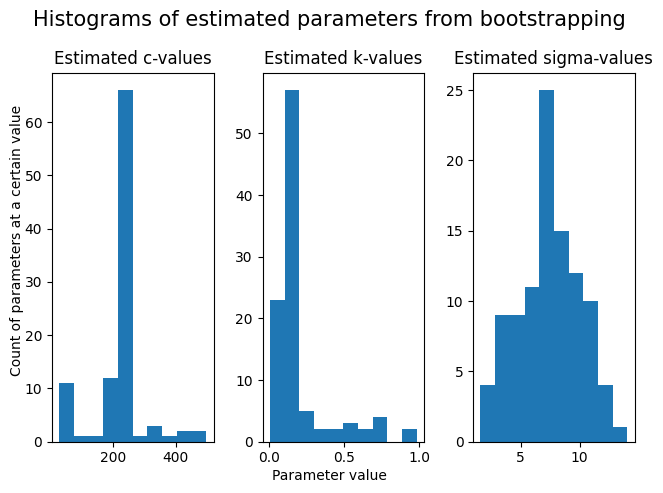

In [ ]:
fig, ax = plt.subplots(1, 3)
ax[0].hist(bootstrap_c);ax[0].set_title("Estimated c-values")
ax[1].hist(bootstrap_k);ax[1].set_title("Estimated k-values")
ax[2].hist(bootstrap_sigma);ax[2].set_title("Estimated sigma-values")
fig.suptitle("Histograms of estimated parameters from bootstrapping", fontsize = 15)
fig.tight_layout()
fig.text(0.0005, 0.5, "Count of parameters at a certain value", va="center", rotation = "vertical")
fig.text(0.5, 0.0005, "Parameter value", ha="center")
plt.show()